# JEPA Pretraining -- Stage 1 (TODO.md item 3)

Pivot from `vision_encoder.ipynb` (DESIGN_LOG 2026-08-16/17): several hours of
ablations on `ls20` (entropy bonus, group_size, gradient clipping, curiosity
bonus, self-imitation replay) never got GRPO to reliably repeat a win --
single-game reward-side fixes don't solve a hard-exploration problem, and
joint GRPO+JEPA training couples policy-gradient noise into the shared
encoder (a risk flagged from the start, never actually removed).

This notebook trains **Eyes + Intuition only** -- no Brain, no policy
gradient, no reward at all -- on transitions collected by a **random**
policy across all 25 offline games. JEPA only needs state coverage, not
successful episodes, so the exploration difficulty that sank GRPO doesn't
apply here. Once validated, these weights seed `vision_encoder.ipynb`'s
Stage 2 GRPO run (TODO item 4) on top of a stable, already-informative
representation instead of a blank one.

## Imports

In [1]:
import os
import random
import time
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
COMP_DIR = Path("/kaggle/input/arc-prize-2026-arc-agi-3") if ON_KAGGLE else Path("../data")
os.environ["OPERATION_MODE"] = "offline"
os.environ["ENVIRONMENTS_DIR"] = str(COMP_DIR / "environment_files")

from arc_agi import Arcade
from arcengine import GameAction, GameState
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Running on Kaggle:", ON_KAGGLE)
print("Environments dir:", os.environ["ENVIRONMENTS_DIR"])
print("Device:", device, "--", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Running on Kaggle: False
Environments dir: ../data/environment_files
Device: cuda -- NVIDIA GeForce RTX 3090


## Model -- Eyes + Intuition only (no Brain)

Verbatim from `vision_encoder.ipynb`'s RoPE-ViT / JEPA classes, minus `Brain`
and the GRPO plumbing. `WorldModel` wires `Eyes` + a frozen EMA `target_eyes`
+ `Intuition` together -- the same JEPA mechanism, trained alone this time.

In [2]:
class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, max_len: int = 4096, theta: float = 10000.0):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        t = torch.arange(max_len, dtype=torch.float32)
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)

    def _rotate_half(self, x: torch.Tensor) -> torch.Tensor:
        x1 = x[..., :self.dim // 2]
        x2 = x[..., self.dim // 2:]
        return torch.cat((-x2, x1), dim=-1)

    def apply_rope(self, x: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor) -> torch.Tensor:
        cos = cos.unsqueeze(0).unsqueeze(1)
        sin = sin.unsqueeze(0).unsqueeze(1)
        return (x * cos) + (self._rotate_half(x) * sin)


class patch_embedding(nn.Module):
    def __init__(self, input_dim, patch_size, output_dim, image_size=64):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.proj = nn.Conv2d(input_dim, output_dim, kernel_size=patch_size, stride=patch_size)
        rows = torch.arange(self.grid_size).repeat_interleave(self.grid_size)
        cols = torch.arange(self.grid_size).repeat(self.grid_size)
        self.register_buffer("rows", rows, persistent=False)
        self.register_buffer("cols", cols, persistent=False)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)


class RoPEAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, grid_size):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim % 4 == 0, "head_dim must be divisible by 4 for 2D axial RoPE"
        self.axial_dim = self.head_dim // 2
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.row_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)
        self.col_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)

    def _apply_2d_rope(self, x, rows, cols):
        x_row, x_col = x[..., :self.axial_dim], x[..., self.axial_dim:]
        row_cos, row_sin = self.row_rope.cos_cached[rows], self.row_rope.sin_cached[rows]
        col_cos, col_sin = self.col_rope.cos_cached[cols], self.col_rope.sin_cached[cols]
        x_row = self.row_rope.apply_rope(x_row, row_cos, row_sin)
        x_col = self.col_rope.apply_rope(x_col, col_cos, col_sin)
        return torch.cat([x_row, x_col], dim=-1)

    def forward(self, x, rows, cols):
        batch_size, seq_len, embed_dim = x.shape
        qkv = self.qkv(x).view(batch_size, seq_len, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = self._apply_2d_rope(q, rows, cols)
        k = self._apply_2d_rope(k, rows, cols)
        attn_out = F.scaled_dot_product_attention(q, k, v)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        return self.out_proj(attn_out)


class RoPETransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, grid_size, ff_dim=None):
        super().__init__()
        ff_dim = ff_dim or embed_dim * 4
        self.attention = RoPEAttention(embed_dim, num_heads, grid_size)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Linear(ff_dim, embed_dim))

    def forward(self, x, rows, cols):
        x = x + self.attention(self.norm1(x), rows, cols)
        x = x + self.mlp(self.norm2(x))
        return x


class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads, num_layers, patch_size):
        super().__init__()
        self.embedding = patch_embedding(input_dim, patch_size, output_dim)
        self.layers = nn.ModuleList([
            RoPETransformerEncoderLayer(output_dim, num_heads, self.embedding.grid_size)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        rows, cols = self.embedding.rows, self.embedding.cols
        for layer in self.layers:
            x = layer(x, rows, cols)
        return self.fc_out(x)


class Eyes(nn.Module):
    """Vision encoder: RoPE-ViT patches, mean-pooled to a single latent z."""
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, x):
        return self.encoder(x).mean(dim=1)


class Intuition(nn.Module):
    """World model: given z_t and the action(s) taken, predicts future
    latent(s) z_hat_{t+1..t+k}. t_horizon=1 here (single-step transitions,
    matching the data collected below) -- vision_encoder.ipynb used
    t_horizon=4 for its open-loop action chunks; either works, the class is
    unchanged."""
    def __init__(self, latent_dim, num_actions, t_horizon, num_heads=4, num_layers=2):
        super().__init__()
        self.t_horizon = t_horizon
        self.action_embed = nn.Embedding(num_actions, latent_dim)
        self.step_embed = nn.Embedding(t_horizon, latent_dim)
        layer = nn.TransformerEncoderLayer(d_model=latent_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.predict_head = nn.Linear(latent_dim, latent_dim)

    def forward(self, z, action_indices):
        batch_size = z.shape[0]
        z_tok = z.unsqueeze(1)
        act_tok = self.action_embed(action_indices)
        step_ids = torch.arange(self.t_horizon, device=z.device).unsqueeze(0).expand(batch_size, -1)
        act_tok = act_tok + self.step_embed(step_ids)
        tokens = torch.cat([z_tok, act_tok], dim=1)
        out = self.transformer(tokens)
        return self.predict_head(out[:, 1:, :])


class WorldModel(nn.Module):
    """Eyes (+ EMA target) + Intuition only -- no Brain, no policy gradient.
    Removes the eyes<->policy coupling that destabilized the joint GRPO+JEPA
    runs in vision_encoder.ipynb (DESIGN_LOG 2026-08-16/17)."""
    def __init__(self, input_dim, latent_dim, patch_size, num_heads, eyes_layers,
                 intuition_layers, num_actions, t_horizon=1, ema_decay=0.99):
        super().__init__()
        self.eyes = Eyes(Transformer(input_dim=input_dim, output_dim=latent_dim, num_heads=num_heads,
                                      num_layers=eyes_layers, patch_size=patch_size))
        self.target_eyes = Eyes(Transformer(input_dim=input_dim, output_dim=latent_dim, num_heads=num_heads,
                                             num_layers=eyes_layers, patch_size=patch_size))
        self.target_eyes.load_state_dict(self.eyes.state_dict())
        for p in self.target_eyes.parameters():
            p.requires_grad_(False)
        self.ema_decay = ema_decay
        self.intuition = Intuition(latent_dim, num_actions, t_horizon, num_heads=num_heads,
                                    num_layers=intuition_layers)

    @torch.no_grad()
    def update_target(self):
        for p_online, p_target in zip(self.eyes.parameters(), self.target_eyes.parameters()):
            p_target.mul_(self.ema_decay).add_(p_online, alpha=1 - self.ema_decay)

    def forward(self, x):
        return self.eyes(x)

    def imagine(self, z, action_indices):
        return self.intuition(z, action_indices)

    @torch.no_grad()
    def target_latent(self, x):
        return self.target_eyes(x)

## Data collection -- random policy across all 25 games

No reward, no model in the loop -- pure random legal actions, just to see
diverse `(frame_t, action_t, frame_{t+1})` transitions. 2 games are held out
entirely for validation (never seen during training).

In [5]:
ACTION_SPACE = [GameAction.ACTION1, GameAction.ACTION2, GameAction.ACTION3,
                 GameAction.ACTION4, GameAction.ACTION5, GameAction.ACTION7]
ACTION_ID_TO_INDEX = {a.value: i for i, a in enumerate(ACTION_SPACE)}

GAMES = sorted(p.name for p in (COMP_DIR / "environment_files").iterdir() if p.is_dir())
print(f"{len(GAMES)} games: {GAMES}")


def collect_random_transitions(env, num_steps, max_episode_steps=200):
    """Random legal-action walk. Resets on WIN/GAME_OVER or after
    max_episode_steps, so a single dead-end episode can't dominate the data.
    Stores grids as uint8 (values 0-15) -- converted to float only when
    building a training batch, to keep the whole dataset in memory cheaply.

    The `env` passed in is assumed usable (see the usability pass below) --
    the early `break` here is just a defensive fallback in case a game gets
    stuck with zero legal actions mid-collection, not the primary filter.
    """
    transitions = []
    frame = env.reset()
    episode_steps = 0
    for _ in range(num_steps):
        if frame.state != GameState.NOT_FINISHED or episode_steps >= max_episode_steps:
            frame = env.reset()
            episode_steps = 0
        legal = [a for a in frame.available_actions if a in ACTION_ID_TO_INDEX]
        if not legal:
            frame = env.reset()
            episode_steps = 0
            legal = [a for a in frame.available_actions if a in ACTION_ID_TO_INDEX]
        if not legal:
            break
        action_idx = ACTION_ID_TO_INDEX[random.choice(legal)]
        grid_t = frame.frame[0].copy().astype(np.uint8)
        frame = env.step(ACTION_SPACE[action_idx])
        grid_next = frame.frame[0].copy().astype(np.uint8)
        transitions.append((grid_t, action_idx, grid_next))
        episode_steps += 1
    return transitions


# Usability pass first: some games apparently never expose any of our
# supported SimpleActions (ACTION1-5,7 -- likely ACTION6/click-only games).
# Checking this *before* picking the held-out split matters -- picking
# VAL_GAMES from the raw game list risks permanently landing on an unusable
# game every single run (this happened: GAMES[-2:] deterministically included
# "vc33", one of the click-only games, wasting half the validation set on
# every run regardless of parameters).
arc = Arcade()
usable_envs = {}
unusable_games = []
for game in tqdm(GAMES, desc="checking usability"):
    env = arc.make(game)
    frame = env.reset()
    if any(a in ACTION_ID_TO_INDEX for a in frame.available_actions):
        usable_envs[game] = env
    else:
        unusable_games.append(game)
print(f"{len(usable_envs)}/{len(GAMES)} games usable -- skipped (no supported action): {unusable_games}")

VAL_GAMES = set(list(usable_envs)[-2:])   # held out entirely -- never trained on
TRAIN_GAMES = [g for g in usable_envs if g not in VAL_GAMES]
print(f"train: {len(TRAIN_GAMES)} games -- held out: {sorted(VAL_GAMES)}")

STEPS_PER_GAME = 30000  # scaled up 2026-08-20 (DESIGN_LOG) -- ~510k train transitions,
                         # a real training run now that Eyes moved off the 3.8K-param/CPU setup

# Cached to disk (2026-08-21, DESIGN_LOG) -- collection takes ~10 min and was
# being fully repeated on every kernel restart even though it's deterministic
# given STEPS_PER_GAME/the game list. `../data/` is already gitignored, so
# this ~4GB cache (510k transitions x two 64x64 uint8 grids each) never risks
# getting committed. Delete the file (or bump CACHE_PATH) to force a
# from-scratch re-collection, e.g. after changing STEPS_PER_GAME.
CACHE_PATH = Path("../data/stage1_transitions_cache.pt")

if CACHE_PATH.exists():
    print(f"loading cached transitions from {CACHE_PATH} (delete this file to force re-collection)")
    t0 = time.time()
    cache = torch.load(CACHE_PATH, weights_only=False)
    train_transitions = cache["train_transitions"]
    val_transitions = cache["val_transitions"]
    print(f"loaded {len(train_transitions)} train transitions across {len(cache['train_games'])} games "
          f"in {time.time()-t0:.0f}s -- cached with STEPS_PER_GAME={cache['steps_per_game']} "
          f"(current setting: {STEPS_PER_GAME}{'  -- MISMATCH, consider deleting the cache' if cache['steps_per_game'] != STEPS_PER_GAME else ''})")
else:
    train_transitions = []
    val_transitions = {}

    t0 = time.time()
    pbar = tqdm(TRAIN_GAMES, desc="collecting (train)")
    for game in pbar:
        trans = collect_random_transitions(usable_envs[game], STEPS_PER_GAME)
        train_transitions.extend(trans)
        pbar.set_postfix(game=game, transitions=len(train_transitions))

    for game in tqdm(sorted(VAL_GAMES), desc="collecting (held out)"):
        val_transitions[game] = collect_random_transitions(usable_envs[game], STEPS_PER_GAME)

    print(f"\nDone in {time.time()-t0:.0f}s -- {len(train_transitions)} train transitions across {len(TRAIN_GAMES)} games")

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"train_transitions": train_transitions, "val_transitions": val_transitions,
                "steps_per_game": STEPS_PER_GAME, "train_games": TRAIN_GAMES,
                "val_games": sorted(VAL_GAMES)}, CACHE_PATH)
    print(f"cached to {CACHE_PATH} -- delete it to force re-collection next time")

25 games: ['ar25', 'bp35', 'cd82', 'cn04', 'dc22', 'ft09', 'g50t', 'ka59', 'lf52', 'lp85', 'ls20', 'm0r0', 'r11l', 're86', 's5i5', 'sb26', 'sc25', 'sk48', 'sp80', 'su15', 'tn36', 'tr87', 'tu93', 'vc33', 'wa30']
INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00


checking usability:   0%|          | 0/25 [00:00<?, ?it/s]

2026-08-21 18:00:02 | INFO | Created new scorecard: 12ffef24-ad24-49df-8afb-f5ae26a3b9de
2026-08-21 18:00:02 | INFO | Found latest version of ar25: ar25-0c556536 (downloaded: 2026-04-08 20:07:48.460282+00:00)
2026-08-21 18:00:02 | INFO | Successfully loaded game class Ar25 from ../data/environment_files/ar25/0c556536/ar25.py
2026-08-21 18:00:02 | INFO | Found latest version of bp35: bp35-0a0ad940 (downloaded: 2026-04-08 20:07:48.891045+00:00)
2026-08-21 18:00:02 | INFO | Successfully loaded game class Bp35 from ../data/environment_files/bp35/0a0ad940/bp35.py
2026-08-21 18:00:02 | INFO | Found latest version of cd82: cd82-fb555c5d (downloaded: 2026-04-08 20:07:49.045128+00:00)
2026-08-21 18:00:02 | INFO | Successfully loaded game class Cd82 from ../data/environment_files/cd82/fb555c5d/cd82.py
2026-08-21 18:00:02 | INFO | Found latest version of cn04: cn04-2fe56bfb (downloaded: 2026-04-08 20:07:49.199835+00:00)
2026-08-21 18:00:02 | INFO | Successfully loaded game class Cn04 from ../data

## JEPA pretraining loop

Plain supervised-style training on the collected buffer -- random minibatches,
no rollouts, no reward, no policy. Same JEPA mechanism as `vision_encoder.ipynb`
(predict `z_{t+1}` from `z_t` + action, compare to a stop-grad EMA target),
just with nothing else touching `eyes`.

eyes params: 2,709,504
intuition params: 3,789,056


JEPA pretraining:   0%|          | 0/20000 [00:00<?, ?it/s]

step     1/20000 | loss   5.9941 | mean(last 1)   5.9941 | lr 6.0e-07
step   500/20000 | loss   0.0574 | mean(last 500)   1.3694 | lr 3.0e-04
step  1000/20000 | loss   0.0649 | mean(last 500)   0.0847 | lr 3.0e-04
step  1500/20000 | loss   0.1081 | mean(last 500)   0.0684 | lr 3.0e-04
step  2000/20000 | loss   0.1630 | mean(last 500)   0.1344 | lr 3.0e-04
step  2500/20000 | loss   0.1785 | mean(last 500)   0.2254 | lr 3.0e-04
step  3000/20000 | loss   0.2098 | mean(last 500)   0.2252 | lr 3.0e-04
step  3500/20000 | loss   0.2059 | mean(last 500)   0.2187 | lr 3.0e-04
early stop at step 3500 -- no improvement over best mean(last 500)=0.0684 at step 1500 for 2000 steps
best mean(last 500) loss: 0.0684 at step 1500 (final step reached: 3500)


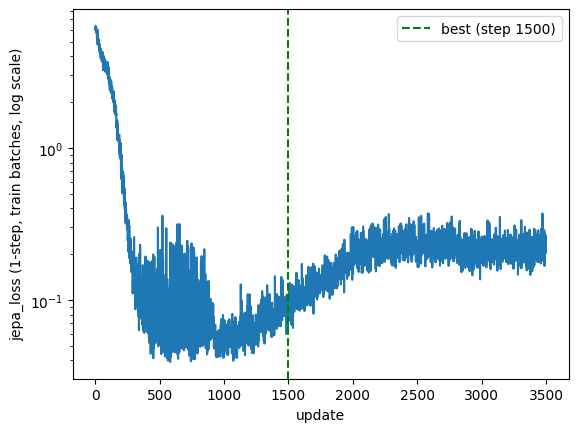

In [4]:
def to_tensor_batch(batch):
    xs = torch.stack([torch.from_numpy(g).float().unsqueeze(0) for g, _, _ in batch])       # (B,1,64,64)
    actions = torch.tensor([a for _, a, _ in batch]).unsqueeze(1)                             # (B,1)
    xs_next = torch.stack([torch.from_numpy(g).float().unsqueeze(0) for _, _, g in batch])    # (B,1,64,64)
    return xs.to(device), actions.to(device), xs_next.to(device)


# eyes_layers/intuition_layers/latent_dim/num_heads/t_horizon must match
# Stage 2's ARC_AGI_3 below (t_horizon=1 specifically -- see the Stage 2
# markdown cell for why: it removes DESIGN_LOG risk #3 entirely instead of
# working around it) -- if you change any of these, change Stage 2's
# ARC_AGI_3(...) call together, or load_pretrained()'s state_dict copy will
# shape-mismatch.
#
# Scaled up 2026-08-20 (DESIGN_LOG): the original 3,824-param/1-layer Eyes
# tested clearly undertrained/unstable (DINOv2 probe notebook -- 66x more
# temporal drift than a random-init ViT on *confirmed-static* patches, the
# worst of three encoders compared). ~2.7M params now (still tiny next to
# DINOv2-small's 22M, but 700x this project's previous size), trained on GPU
# with more data/steps -- a first real capacity+budget attempt, not another
# token-sized smoke test.
model = WorldModel(input_dim=1, latent_dim=192, patch_size=4, num_heads=6, eyes_layers=6,
                    intuition_layers=4, num_actions=len(ACTION_SPACE), t_horizon=1).to(device)

BASE_LR = 3e-4     # lowered from 1e-3 (2026-08-20) -- 1e-3 was tuned for the old 1-layer/7.6K-param
                   # model; plain Adam at that rate with no warmup is a common source of early
                   # instability for a 6-layer transformer trained from scratch.
WARMUP_STEPS = 500  # linear ramp 0 -> BASE_LR, standard stabilizer for deeper transformers,
                    # had nothing like it before since the old model didn't need it.
optimizer = torch.optim.Adam(model.parameters(), lr=BASE_LR)

print(f"eyes params: {sum(p.numel() for p in model.eyes.parameters()):,}")
print(f"intuition params: {sum(p.numel() for p in model.intuition.parameters()):,}")

epochs = 20000
batch_size = 256
log_every = 500  # periodic snapshot via pbar.write -- survives in the notebook's saved output,
                 # unlike tqdm's postfix (only ever shows the latest value) -- added 2026-08-20
                 # after not being able to tell "high but stable" from "diverging" mid-run.

# Early stopping (2026-08-20, DESIGN_LOG): the first big run wasn't a stable
# plateau -- loss dropped fast to ~0.05 by step ~2500, then climbed steadily
# to ~0.9-1.0 by step 20000. The saved checkpoint was the *final* (worst,
# most-degraded) weights, not the best ones -- explains the DINOv2-probe
# regression on static-patch stability after "scaling up." Now tracks the
# best smoothed loss and its weights separately, and stops once it's clearly
# past the optimum instead of always running the full epoch budget.
PATIENCE_CHECKS = 4  # x log_every steps (4x500=2000) with no improvement -> stop
best_mean_loss = float("inf")
best_step = None
best_eyes_state = None
best_intuition_state = None
checks_since_improvement = 0

jepa_loss_history = []

pbar = tqdm(range(epochs), desc="JEPA pretraining")
for step in pbar:
    lr = BASE_LR * min(1.0, (step + 1) / WARMUP_STEPS)
    for g in optimizer.param_groups:
        g["lr"] = lr

    batch = random.sample(train_transitions, batch_size)
    xs, actions, xs_next = to_tensor_batch(batch)

    z = model(xs)                        # (B, 192)
    preds = model.imagine(z, actions)    # (B, 1, 192)
    with torch.no_grad():
        targets = model.target_latent(xs_next).unsqueeze(1)  # (B, 1, 192)
    loss = F.mse_loss(preds, targets)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    model.update_target()

    jepa_loss_history.append(loss.item())
    pbar.set_postfix(jepa_loss=f"{loss.item():.4f}", lr=f"{lr:.1e}", best=f"{best_mean_loss:.4f}")

    if (step + 1) % log_every == 0 or step == 0:
        recent = jepa_loss_history[-log_every:]
        mean_loss = sum(recent) / len(recent)
        pbar.write(f"step {step+1:5d}/{epochs} | loss {loss.item():8.4f} | "
                   f"mean(last {len(recent)}) {mean_loss:8.4f} | lr {lr:.1e}")

        if mean_loss < best_mean_loss:
            best_mean_loss = mean_loss
            best_step = step + 1
            best_eyes_state = {k: v.detach().clone().cpu() for k, v in model.eyes.state_dict().items()}
            best_intuition_state = {k: v.detach().clone().cpu() for k, v in model.intuition.state_dict().items()}
            checks_since_improvement = 0
        else:
            checks_since_improvement += 1
            if checks_since_improvement >= PATIENCE_CHECKS:
                pbar.write(f"early stop at step {step+1} -- no improvement over best "
                           f"mean(last {log_every})={best_mean_loss:.4f} at step {best_step} "
                           f"for {PATIENCE_CHECKS * log_every} steps")
                break

print(f"best mean(last {log_every}) loss: {best_mean_loss:.4f} at step {best_step} "
      f"(final step reached: {len(jepa_loss_history)})")

plt.plot(jepa_loss_history)
plt.axvline(best_step - 1, color="green", linestyle="--", label=f"best (step {best_step})")
plt.yscale("log")
plt.xlabel("update"); plt.ylabel("jepa_loss (1-step, train batches, log scale)")
plt.legend()
plt.show()

## Validation -- held-out games

TODO.md item 3's third checkbox: check k-step (here 1-step) prediction error
on trajectories/games never seen during training, before trusting this for
anything downstream.

In [4]:
# Restore the BEST tracked checkpoint into `model` before evaluating
# (DESIGN_LOG 2026-08-20) -- `model`'s live weights are whatever the loop
# ended on, which early stopping may have already run PATIENCE_CHECKS*
# log_every steps past. Validate (and, in the next cell, save) the same
# weights, not two different snapshots of the run.
if "best_eyes_state" in dir() and best_eyes_state is not None:
    model.eyes.load_state_dict(best_eyes_state)
    model.intuition.load_state_dict(best_intuition_state)
    model.eyes.to(device); model.intuition.to(device)
    print(f"restored best checkpoint (step {best_step}, mean loss {best_mean_loss:.4f}) before validation")


@torch.no_grad()
def eval_prediction_error(model, transitions, n=500):
    if not transitions:
        return None
    batch = random.sample(transitions, min(n, len(transitions)))
    xs, actions, xs_next = to_tensor_batch(batch)
    z = model(xs)
    preds = model.imagine(z, actions)
    targets = model.target_latent(xs_next).unsqueeze(1)
    return F.mse_loss(preds, targets).item()


train_err = eval_prediction_error(model, train_transitions)
print(f"{'train games (seen)':<24} 1-step prediction MSE = {train_err:.4f}")
for game, trans in val_transitions.items():
    err = eval_prediction_error(model, trans)
    if err is None:
        print(f"{'held out: ' + game:<24} skipped -- no supported action in this game")
    else:
        print(f"{'held out: ' + game:<24} 1-step prediction MSE = {err:.4f}")

NameError: name 'model' is not defined

## Save weights

Reload `eyes` (and `intuition`, if reusing it too) in `vision_encoder.ipynb`'s
`ARC_AGI_3` before starting Stage 2 GRPO, instead of a random init.

In [3]:
checkpoint_dir = Path("../checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

# Save the BEST checkpoint tracked during training (early stopping,
# DESIGN_LOG 2026-08-20), not model's current (final, possibly degraded)
# weights -- falls back to current weights only if early stopping never ran
# (e.g. this cell re-executed standalone without the training loop above).
eyes_state = best_eyes_state if "best_eyes_state" in dir() and best_eyes_state is not None else model.eyes.state_dict()
intuition_state = (best_intuition_state if "best_intuition_state" in dir() and best_intuition_state is not None
                    else model.intuition.state_dict())

torch.save({"eyes": eyes_state, "intuition": intuition_state},
           checkpoint_dir / "world_model_pretrained.pt")
print(f"saved to {checkpoint_dir / 'world_model_pretrained.pt'}"
      + (f" (best checkpoint, step {best_step})" if "best_step" in dir() and best_step else " (current weights)"))

NameError: name 'model' is not defined

## Stage 2 -- GRPO policy training on the pretrained world model (TODO item 4)

**Restarted from scratch, 2026-08-21 (DESIGN_LOG).** The previous version of
this section fine-tuned `eyes`/`intuition` jointly with the policy via a
JEPA loss folded into the same combined loss, plus a growing stack of
extras (PPO clip/KL trust region, Go-Explore archive, self-imitation replay
buffer, curiosity). The real run showed a concrete failure: once
`jepa_loss` chronically saturated (rollouts drifted into states the
early-stopped Stage 1 checkpoint predicts badly), its gradient dominated
the single `clip_grad_norm_` call over *all* parameters, crushing the
policy's own gradient to near-zero -- reward flat-lined by step ~75 while
the run kept logging as if alive. Separately, the DINOv2 probe
(`dino_probe.ipynb`) suggested the trained `Eyes` encoder's patch
representations are *less* visually legible than a random-init encoder of
the same architecture -- more training hasn't obviously been buying
anything qualitatively.

This version is a minimal vanilla GRPO baseline instead of another patch:

- **`eyes` is frozen** (`requires_grad_(False)`, forward wrapped in
  `torch.no_grad()`) -- Stage 1's checkpoint is used as-is, no further
  training of the vision encoder here. Removes the eyes<->policy coupling
  structurally instead of managing it.
- **`intuition` is not loaded or used at all** in this section -- no JEPA
  loss, no curiosity, no latent imagination. Just real-env rollouts scored
  by `compute_reward`.
- **No PPO clip/KL, no archive, no replay buffer.** One collected group ->
  one group-relative-advantage gradient pass (chunked into memory-safe
  minibatches, but a single pass, not `ppo_epochs` reuse).
- **Zero-variance-trap check kept** (DESIGN_LOG 2026-08-20) -- skip the
  update if the group's reward std is ~0, since group-relative advantage
  would otherwise silently produce a dead gradient.
- **Finite-loss/grad safety net kept** -- cheap, prevents any non-finite
  step from corrupting weights, not really "complexity" so much as a
  one-line guard.

If this trains cleanly (reward actually moving, not just losses cycling),
re-add pieces one at a time only if a concrete failure mode calls for them,
each validated against the real env before layering on the next.


In [11]:
class Brain(nn.Module):
    """From-scratch reasoning transformer ("brain"): takes the eyes latent
    z_t plus N learned role-queries (not tokenized text -- no pretrained
    language prior to exploit here), predicts one action distribution.
    """
    def __init__(self, latent_dim, num_actions, num_queries=4, num_heads=4, num_layers=2):
        super().__init__()
        self.num_actions = num_actions
        self.latent_proj = nn.Linear(latent_dim, latent_dim)
        self.queries = nn.Parameter(torch.randn(num_queries, latent_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(d_model=latent_dim, nhead=num_heads, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.action_head = nn.Linear(latent_dim, num_actions)

    def forward(self, z):
        batch_size = z.shape[0]
        z_tok = self.latent_proj(z).unsqueeze(1)
        query_tok = self.queries.unsqueeze(0).expand(batch_size, -1, -1)
        tokens = torch.cat([z_tok, query_tok], dim=1)
        out = self.transformer(tokens)
        pooled = out.mean(dim=1)
        return self.action_head(pooled)  # (batch, num_actions)


class Policy(nn.Module):
    """Frozen Stage 1 `eyes` -> trainable `brain` (2026-08-21 GRPO restart,
    see the markdown above for why: the previous version's joint JEPA
    fine-tuning let a saturated JEPA gradient crush the policy gradient via
    a shared `clip_grad_norm_` call). `intuition` is not part of this class
    at all -- no world-model use in this version of Stage 2.
    """
    def __init__(self, input_dim, latent_dim, patch_size, num_heads, eyes_layers,
                 brain_layers, num_actions, num_queries=4):
        super().__init__()
        self.eyes = Eyes(Transformer(input_dim=input_dim, output_dim=latent_dim, num_heads=num_heads,
                                      num_layers=eyes_layers, patch_size=patch_size))
        for p in self.eyes.parameters():
            p.requires_grad_(False)
        self.brain = Brain(latent_dim, num_actions, num_queries=num_queries,
                            num_heads=num_heads, num_layers=brain_layers)

    def load_pretrained_eyes(self, checkpoint_path):
        ckpt = torch.load(checkpoint_path, map_location="cpu")
        self.eyes.load_state_dict(ckpt["eyes"])

    def forward(self, x):
        self.eyes.eval()
        with torch.no_grad():
            z = self.eyes(x)  # (batch, latent_dim) -- no grad, eyes are frozen
        return self.brain(z)  # (batch, num_actions)


In [12]:
# latent_dim/num_heads/eyes_layers must match the checkpoint that Stage 1
# saved (192/6/6, see the JEPA pretraining loop markdown/comments above).
policy = Policy(input_dim=1, latent_dim=192, patch_size=4, num_heads=6, eyes_layers=6,
                 brain_layers=1, num_actions=len(ACTION_SPACE), num_queries=4).to(device)
policy.load_pretrained_eyes(Path("../checkpoints/world_model_pretrained.pt"))


def count_parameters(module):
    return sum(p.numel() for p in module.parameters())


print(f"{'eyes (frozen, pretrained)':<26} {count_parameters(policy.eyes):>10,}")
print(f"{'brain (fresh, trainable)':<26} {count_parameters(policy.brain):>10,}")


eyes (frozen, pretrained)   2,709,504
brain (fresh, trainable)      976,646


In [13]:
def frame_to_tensor(frame):
    grid = frame.frame[0]  # (64, 64), int8 values 0-15
    return torch.from_numpy(grid).float().unsqueeze(0).unsqueeze(0).to(device)  # (1, 1, 64, 64)


def compute_reward(prev_frame, frame):
    """Generic reward only -- Δlevels_completed + WIN/GAME_OVER + step
    penalty. No per-game shaping (see feedback_no_game_hacking memory)."""
    reward = float(frame.levels_completed - prev_frame.levels_completed)
    if frame.state == GameState.WIN:
        reward += 1.0
    elif frame.state == GameState.GAME_OVER:
        reward -= 1.0
    reward -= 0.01
    return reward


def collect_group(envs, model, group_size, max_steps=120):
    """Lockstep-vectorized collection (kept from the previous Stage 2,
    DESIGN_LOG 2026-08-21 -- a genuine perf fix, not part of the complexity
    rolled back in this restart): batches the model forward pass across
    every currently active rollout at each timestep instead of stepping
    `group_size` rollouts one at a time. Needs one independent env instance
    per rollout slot (`envs`).

    No archive, no curiosity (both dropped in the restart -- see the Stage 2
    markdown). Every rollout starts from a fresh `reset()`.
    """
    frames, trajectories = [], []
    for i in range(group_size):
        frame = envs[i].reset()
        frames.append(frame)
        trajectories.append([{"grid": frame.frame[0].copy(), "action": None, "reward": 0.0}])

    steps_per_rollout = [[] for _ in range(group_size)]
    active = [True] * group_size

    for _ in range(max_steps):
        idxs, legal_lists = [], {}
        for i in range(group_size):
            if not active[i]:
                continue
            if frames[i].state != GameState.NOT_FINISHED:
                active[i] = False
                continue
            legal = [a for a in frames[i].available_actions if a in ACTION_ID_TO_INDEX]
            if not legal:
                active[i] = False
                continue
            legal_lists[i] = legal
            idxs.append(i)

        if not idxs:
            break

        xs = torch.cat([frame_to_tensor(frames[i]) for i in idxs], dim=0)  # (M, 1, 64, 64)
        with torch.no_grad():
            logits = model(xs)  # (M, num_actions)

        masks = torch.full((len(idxs), len(ACTION_SPACE)), float("-inf"), device=device)
        for row, i in enumerate(idxs):
            for action_id in legal_lists[i]:
                masks[row, ACTION_ID_TO_INDEX[action_id]] = 0.0

        dist = torch.distributions.Categorical(logits=logits + masks)
        action_idxs = dist.sample()  # (M,)

        for row, i in enumerate(idxs):
            action_idx = action_idxs[row]
            prev_frame = frames[i]
            frame = envs[i].step(ACTION_SPACE[action_idx.item()])
            frames[i] = frame
            reward = compute_reward(prev_frame, frame)
            trajectories[i].append({"grid": frame.frame[0].copy(),
                                     "action": ACTION_SPACE[action_idx.item()], "reward": reward})
            steps_per_rollout[i].append(dict(x=xs[row:row + 1], mask=masks[row],
                                              action_idx=action_idx.detach(), reward=reward))

    rollouts = []
    for i in range(group_size):
        total_reward = sum(s["reward"] for s in steps_per_rollout[i])
        rollouts.append(dict(steps=steps_per_rollout[i], trajectory=trajectories[i], reward=total_reward))
    return rollouts


def live_rollouts_of(rollouts):
    """Rollouts with at least one live step -- a rollout can have zero steps
    if the very first frame is already terminal or has no legal action."""
    return [r for r in rollouts if r["steps"]]


def episode_rewards_of(rollouts):
    return torch.tensor([r["reward"] for r in live_rollouts_of(rollouts)])


def flatten_steps_with_advantage(rollouts):
    """Group-relative advantage (GRPO) needs the full group's episode
    rewards to normalize -- computed once here, then flattened to
    (step, advantage) pairs for minibatched loss computation."""
    live = live_rollouts_of(rollouts)
    if not live:
        return []
    episode_rewards = torch.tensor([r["reward"] for r in live])
    advantages = (episode_rewards - episode_rewards.mean()) / (episode_rewards.std() + 1e-8)
    flat = []
    for r, advantage in zip(live, advantages):
        for s in r["steps"]:
            flat.append((s, advantage))
    return flat


def compute_losses(minibatch, model):
    """Vanilla group-relative policy gradient (2026-08-21 GRPO restart) --
    no PPO clip, no KL trust region, no importance ratio: each collected
    group is used for exactly one gradient pass, so there's no policy drift
    within a group to bound. `logits` are recomputed here with grad enabled
    (collection ran under `torch.no_grad()`)."""
    xs = torch.cat([s["x"] for s, _ in minibatch], dim=0)
    masks = torch.stack([s["mask"] for s, _ in minibatch])
    action_idxs = torch.stack([s["action_idx"] for s, _ in minibatch])
    advantages = torch.stack([adv for _, adv in minibatch]).to(xs.device)

    logits = model(xs)
    dist = torch.distributions.Categorical(logits=logits + masks)
    log_probs = dist.log_prob(action_idxs)

    policy_loss = -(advantages * log_probs).mean()
    entropy = dist.entropy().mean()
    return policy_loss, entropy


def update_best_run(best_run, rollouts):
    for r in rollouts:
        if r["reward"] > best_run["reward"]:
            best_run["reward"] = r["reward"]
            best_run["trajectory"] = r["trajectory"]
    return best_run


def render_trajectory(trajectory, interval=300):
    from matplotlib.animation import FuncAnimation
    from IPython.display import HTML

    fig, ax = plt.subplots()
    im = ax.imshow(trajectory[0]["grid"], vmin=0, vmax=15)
    ax.axis("off")
    title = ax.set_title("step 0 (reset)")

    def label(entry, i):
        if entry["action"] is None:
            return f"step {i} (reset)"
        return f"step {i} | action {entry['action'].name} | reward {entry['reward']:+.3f}"

    def update(i):
        entry = trajectory[i]
        im.set_data(entry["grid"])
        title.set_text(label(entry, i))
        return im, title

    anim = FuncAnimation(fig, update, frames=len(trajectory), interval=interval, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-21 20:21:04 | INFO | Found lates

Stage 2 GRPO (vanilla):   0%|          | 0/30 [00:00<?, ?it/s]

step    1/30 | loss  +0.000 | entropy 0.000 | reward -1.200 | best -1.200 | std 0.0000 | skipped 1 | nan_skips 0
step   20/30 | loss  +0.000 | entropy 0.000 | reward -1.200 | best -1.200 | std 0.0000 | skipped 20 | nan_skips 0


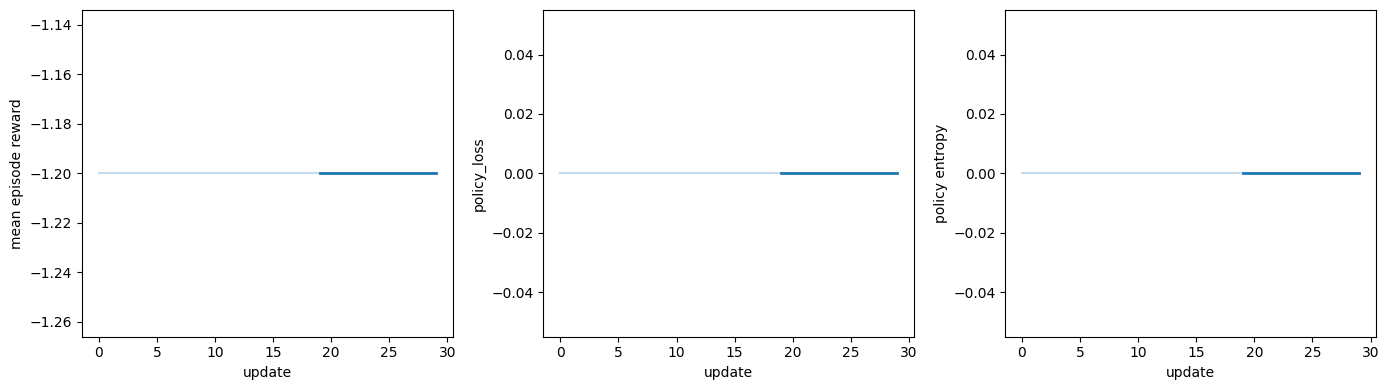

In [14]:
from IPython.display import display

GAME = "ls20"  # same game as the vision_encoder.ipynb ablations, for direct comparison

epochs = 30
group_size = 24        # matches the H1-H4 / replay ablations' group_size

# One independent env instance per group slot -- collect_group batches the
# model forward pass across all *active* rollouts at each timestep, which
# needs each rollout to have its own real-engine state. Created once,
# reused every outer step.
envs = [arc.make(GAME) for _ in range(group_size)]
max_steps = 120   # kept from the previous run (DESIGN_LOG 2026-08-21) -- every win found this
                  # whole session (archive-chained or not) needed 48-96 live steps; anything
                  # shorter structurally prevents a live rollout from ever reaching one.
entropy_coef = 0.001
grad_clip_norm = 1.0
minibatch_size = 128  # memory-safe chunking -- each step is a 256-patch-token sequence, so
                      # batched-attention memory doesn't scale with parameter count alone.
reward_std_eps = 1e-4  # group reward std at/below this = zero-variance trap (DAPO-style,
                       # DESIGN_LOG 2026-08-20) -- skip the update rather than spend it on a
                       # group-relative advantage that's identically zero everywhere.

log_every = 20
plot_every = 20


def moving_average(values, window=20):
    if len(values) < window:
        return [np.nan] * len(values)
    cumsum = np.cumsum(np.insert(np.array(values, dtype=float), 0, 0))
    ma = (cumsum[window:] - cumsum[:-window]) / window
    return [np.nan] * (window - 1) + list(ma)


def plot_progress(reward_history, loss_history, entropy_history, window=20):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    def plot_with_trend(ax, values, ylabel):
        line, = ax.plot(values, alpha=0.25)
        ax.plot(moving_average(values, window), color=line.get_color(), linewidth=2)
        ax.set_xlabel("update"); ax.set_ylabel(ylabel)

    plot_with_trend(axes[0], reward_history, "mean episode reward")
    plot_with_trend(axes[1], loss_history, "policy_loss")
    plot_with_trend(axes[2], entropy_history, "policy entropy")
    plt.tight_layout()
    return fig


# eyes are frozen (Policy.__init__ already set requires_grad_(False)) --
# optimizer only ever sees brain params, kept explicit rather than relying
# on that implicitly.
optimizer = torch.optim.Adam(policy.brain.parameters(), lr=0.001)

reward_history, loss_history, entropy_history = [], [], []
best_run = {"reward": float("-inf"), "trajectory": None}
skipped_updates = 0   # groups whose reward std stayed ~0 -- update skipped, dead gradient avoided
nan_skips = 0         # minibatches skipped for a non-finite loss or (post-clip) gradient

plot_handle = None
pbar = tqdm(range(epochs), desc="Stage 2 GRPO (vanilla)")
for step in pbar:
    rollouts = collect_group(envs, policy, group_size, max_steps)
    best_run = update_best_run(best_run, rollouts)

    mean_reward = sum(r["reward"] for r in rollouts) / len(rollouts)
    live = live_rollouts_of(rollouts)
    task_std = episode_rewards_of(rollouts).std().item() if live else 0.0

    if task_std <= reward_std_eps:
        skipped_updates += 1
        loss = entropy = torch.tensor(0.0)
    else:
        flat_steps = flatten_steps_with_advantage(rollouts)
        random.shuffle(flat_steps)
        for mb_start in range(0, len(flat_steps), minibatch_size):
            minibatch = flat_steps[mb_start:mb_start + minibatch_size]
            loss, entropy = compute_losses(minibatch, policy)
            total_loss = loss - entropy_coef * entropy

            # Finite-loss/grad safety net (kept from the previous version --
            # cheap, prevents a non-finite step from corrupting weights).
            optimizer.zero_grad()
            if torch.isfinite(total_loss):
                total_loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(policy.brain.parameters(), max_norm=grad_clip_norm)
                if torch.isfinite(grad_norm):
                    optimizer.step()
                else:
                    optimizer.zero_grad()
                    nan_skips += 1
            else:
                nan_skips += 1

    reward_history.append(mean_reward)
    loss_history.append(loss.item())
    entropy_history.append(entropy.item())
    pbar.set_postfix(loss=f"{loss.item():.3f}", reward=f"{mean_reward:.3f}",
                      best=f"{best_run['reward']:.3f}", skipped=skipped_updates)

    if (step + 1) % log_every == 0 or step == 0:
        pbar.write(f"step {step+1:4d}/{epochs} | loss {loss.item():+7.3f} | entropy {entropy.item():5.3f} | "
                   f"reward {mean_reward:+6.3f} | best {best_run['reward']:+6.3f} | "
                   f"std {task_std:6.4f} | skipped {skipped_updates} | nan_skips {nan_skips}")

    if (step + 1) % plot_every == 0 or step == epochs - 1:
        fig = plot_progress(reward_history, loss_history, entropy_history)
        if plot_handle is None:
            plot_handle = display(fig, display_id=True)
        else:
            plot_handle.update(fig)
        plt.close(fig)


In [10]:
# Watch the single best episode seen across the whole training run.
print(f"best episode reward: task={best_run['reward']:.3f}  ({len(best_run['trajectory'])} frames)")
render_trajectory(best_run["trajectory"])

best episode reward: task=-0.200  (121 frames)
